# Credit Risk Analysis: Executive Summary

This notebook presents a comprehensive credit risk analysis of a multi-year loan portfolio using
rating migration, Probability of Default (PD), Loss Given Default (LGD), Exposure at Default (EAD),
and Expected Loss (EL) frameworks.

### Key Findings
- Portfolio Probability of Default (PD) shows year-to-year volatility, indicating sensitivity to credit migration.
- Expected Loss (EL) increases under stress scenarios driven by higher LGD and adverse rating migrations.
- Stability analysis shows that higher-rated buckets (AAA, AA) exhibit significantly lower migration risk.
- Portfolio composition analysis reveals periods of increasing exposure to high-risk rating categories (BB–D),
  acting as a leading indicator of future credit deterioration.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
import warnings
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as mtick

warnings.filterwarnings('ignore')

# Setting up the visual style for the plots.
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# This ensures all my charts follow the correct hierarchy from Best to Worst.
RATING_ORDER = ['AAA', 'AA', 'A', 'BBB', 'BB', 'B', 'C', 'D']

# Good ratings are cool colors (Blue/Green), bad ratings are warm (Red/Orange).
RATING_COLORS = {
     'AAA': '#1f77b4', 'AA': '#aec7e8', 'A': '#ff7f0e', 'BBB': '#ffbb78',
     'BB': '#2ca02c', 'B': '#98df8a', 'C': '#d62728', 'D': '#ff9896'
}

# A generic color list for charts that don't need specific rating colors.
COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# This will allow me to calculate a "Weighted Average Risk" score later on
# to see if the portfolio quality is trending up or down numerically.
RISK_SCORES = {r: i+1 for i, r in enumerate(RATING_ORDER)}

print("Initialization done. Libraries loaded and global settings are ready.")

Initialization done. Libraries loaded and global settings are ready.


In [5]:
# Load the Excel file with multi-level headers
df = pd.read_excel(
    r"C:\Users\ASUS\Desktop\projects\Credit risk data.xlsx",
    header=[0, 1]
)
# Drop completely empty rows and columns
df=df.dropna(axis=0, how='all')
df=df.dropna(axis=1, how='all')

# Rename the first level column and set multi-index
df = df.rename(
    columns={'Unnamed: 0_level_0':'zero'},
    level=0
)
# Setting the 'Borrower Number' as the index
df = df.set_index(('zero','Borrower Number'))
df.index.name = 'Borrower Number'
print(list(df.columns))

df.head() # Displaying the first few rows to verify the structure

[('Set', 'Year 1'), ('Set', 'Year 2'), ('Set', 'Year 3'), ('Set', 'Year 4'), ('Set', 'Year 5'), ('Set', 'Year 6'), ('Set', 'Year 7'), ('Set', 'Year 8'), ('Set', 'Year 9'), ('Set', 'Year 10'), ('Ratings', 'Year 1'), ('Ratings', 'Year 2'), ('Ratings', 'Year 3'), ('Ratings', 'Year 4'), ('Ratings', 'Year 5'), ('Ratings', 'Year 6'), ('Ratings', 'Year 7'), ('Ratings', 'Year 8'), ('Ratings', 'Year 9'), ('Ratings', 'Year 10'), ('Amount in Rs Crore', 'Year 1'), ('Amount in Rs Crore', 'Year 2'), ('Amount in Rs Crore', 'Year 3'), ('Amount in Rs Crore', 'Year 4'), ('Amount in Rs Crore', 'Year 5'), ('Amount in Rs Crore', 'Year 6'), ('Amount in Rs Crore', 'Year 7'), ('Amount in Rs Crore', 'Year 8'), ('Amount in Rs Crore', 'Year 9'), ('Amount in Rs Crore', 'Year 10'), ('Loss Given Default', 'Year 1'), ('Loss Given Default', 'Year 2'), ('Loss Given Default', 'Year 3'), ('Loss Given Default', 'Year 4'), ('Loss Given Default', 'Year 5'), ('Loss Given Default', 'Year 6'), ('Loss Given Default', 'Year 7')

Set                                                   \
                Year 1 Year 2 Year 3 Year 4 Year 5 Year 6 Year 7 Year 8   
Borrower Number                                                           
1                    2      2      5      7      3      5      7      6   
2                    8      6      8      3      4      6      5      4   
3                    1      1      4      3      3      7      4      1   
4                    3      5      6      3      4      7      8      6   
5                    7      7      4      6      5      5      8      8   

                                ...  \
                Year 9 Year 10  ...   
Borrower Number                 ...   
1                    3       5  ...   
2                    7       8  ...   
3                    6       3  ...   
4                    2       5  ...   
5                    5       1  ...   

                Exposure at Default (As multiple of Amount in Rs Crore)   \
                                                                  Year 1   
Borrower Number                                                            
1                                                         1.704366         
2                                                         1.863487         
3                                                         1.777882         
4                                                         1.910059         
5                                                         1.055560         

                                                                             \
                   Year 2    Year 3    Year 4    Year 5    Year 6    Year 7   
Borrower Number                                                               
1                1.900729  1.730790  1.999210  1.174419  1.095884  1.214159   
2                1.274270  1.298221  1.103835  1.194516  1.682967  1.436145   
3                1.626529  1.731696  1.474712  1.521086  1.315789  1.687373   
4                1.295447  1.317993  1.335351  1.994691  1.238417  1.574792   
5                1.691969  1.328013  1.952537  1.434545  1.671459  1.140694   

                                               
                   Year 8    Year 9   Year 10  
Borrower Number                                
1                1.253551  1.469032  1.596706  
2                1.010236  1.752144  1.420622  
3                1.999592  1.909357  1.289968  
4                1.584953  1.618272  1.725727  
5                1.495779  1.783463  1.188152  

[5 rows x 50 columns]

In [6]:
# Extracting specific columns for analysis
df_set = df['Set']
df_ratings = df['Ratings']
df_Amount = df['Amount in Rs Crore']
df_ead = df['Exposure at Default (As multiple of Amount in Rs Crore) ']
df_lgd = df['Loss Given Default']


# Displaying the first few rows of each extracted DataFrame
print(df_set.head())
print(df_ratings.head())
print(df_Amount.head())
print(df_ead.head())
print(df_lgd.head())

# getting the year names from the first row of the file
# and cleaning them up to remove any accidental spaces
year_values = df.iloc[0, 11:21].tolist()    
YEARS = [str(y).strip() for y in year_values]
YEAR_LABELS = [f"Year {i+1}" for i in range(len(YEARS))]


# cleaning up the rating values
# replacing any "GR 1", "GR 2" stuff with just "D"
df_ratings = df_ratings.replace(r"GR\s*\d+", "D", regex=True)



print(f"✅ Data loaded successfully: {df_ratings.shape[0]} borrowers, {len(YEARS)} years")

                 Year 1  Year 2  Year 3  Year 4  Year 5  Year 6  Year 7  \
Borrower Number                                                           
1                     2       2       5       7       3       5       7   
2                     8       6       8       3       4       6       5   
3                     1       1       4       3       3       7       4   
4                     3       5       6       3       4       7       8   
5                     7       7       4       6       5       5       8   

                 Year 8  Year 9  Year 10  
Borrower Number                           
1                     6       3        5  
2                     4       7        8  
3                     1       6        3  
4                     6       2        5  
5                     8       5        1  
                Year 1 Year 2 Year 3 Year 4 Year 5 Year 6 Year 7 Year 8  \
Borrower Number                                                           
1                   AA 

# Exploratory Data Analysis


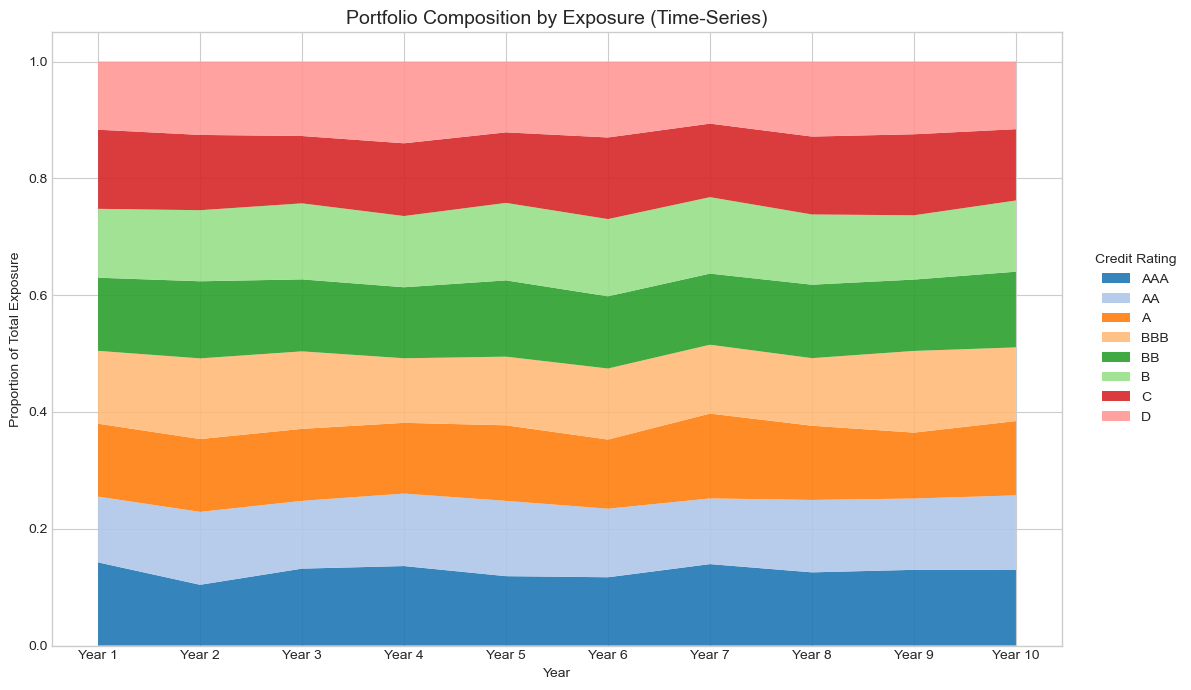

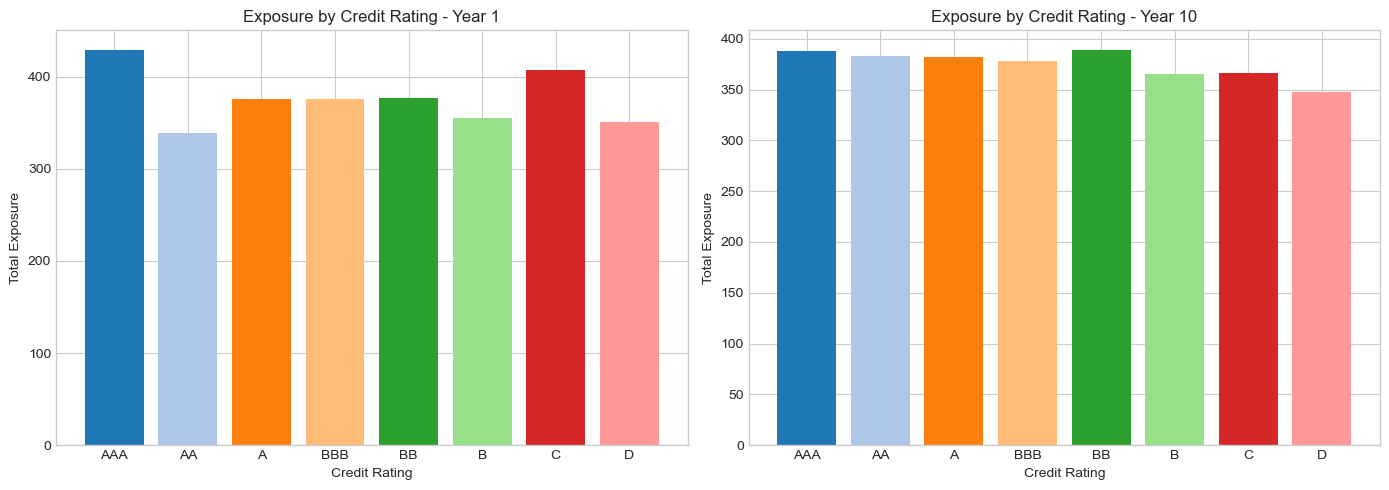

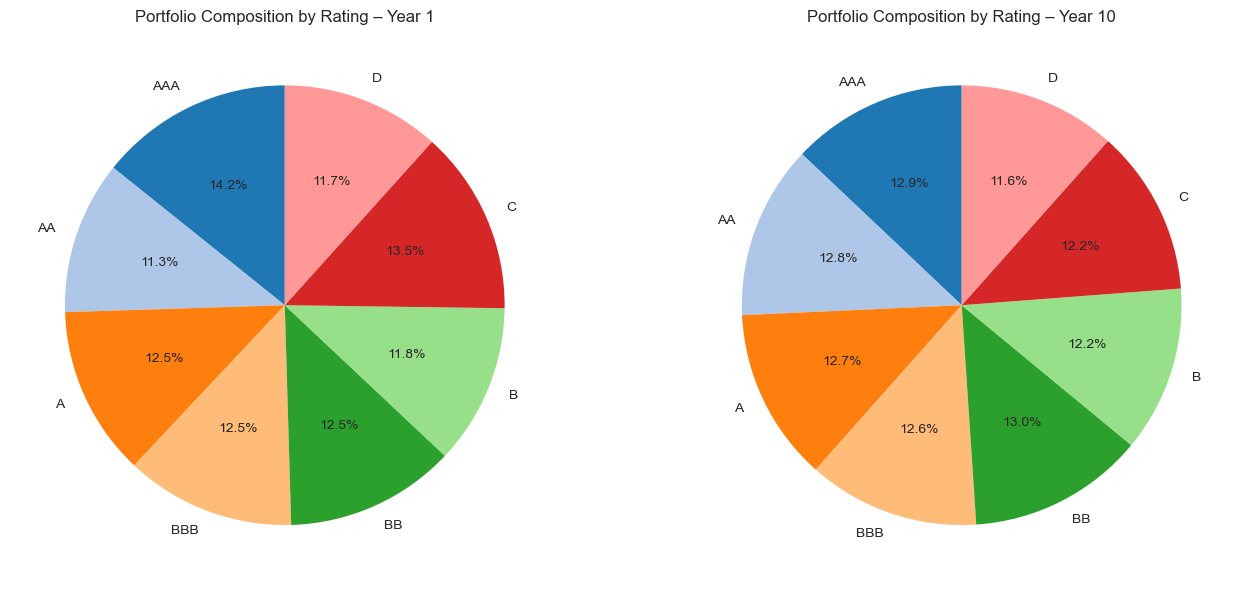

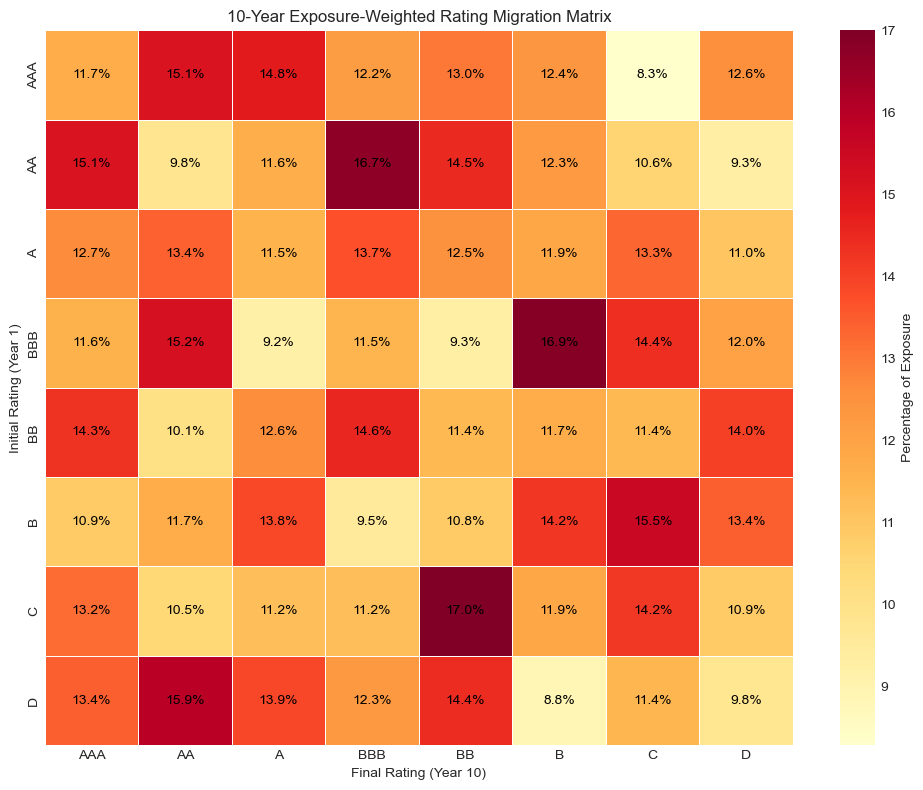

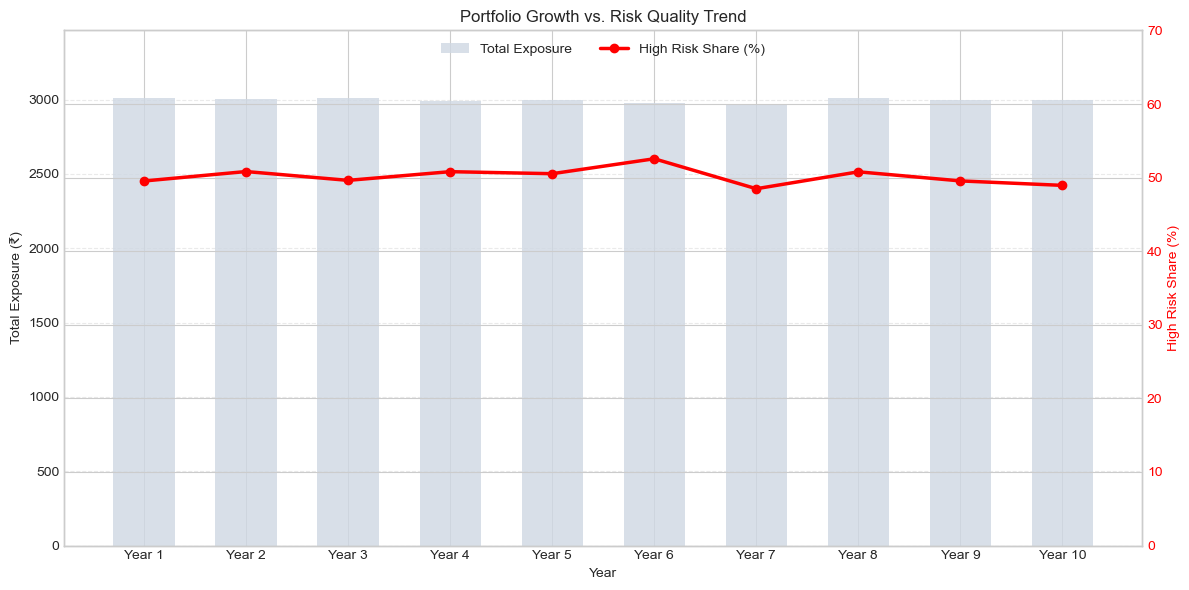

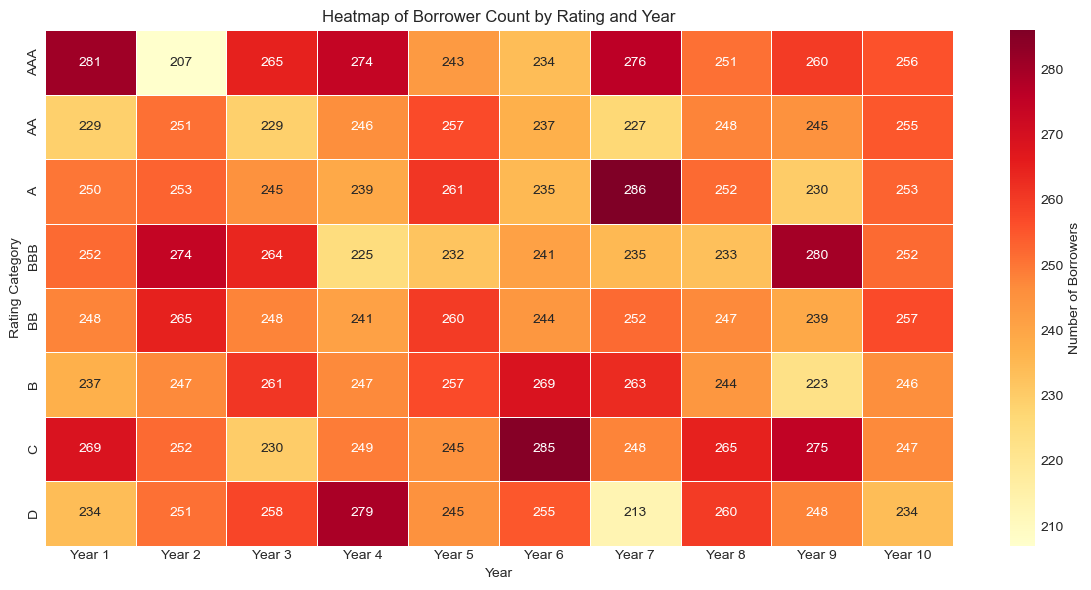

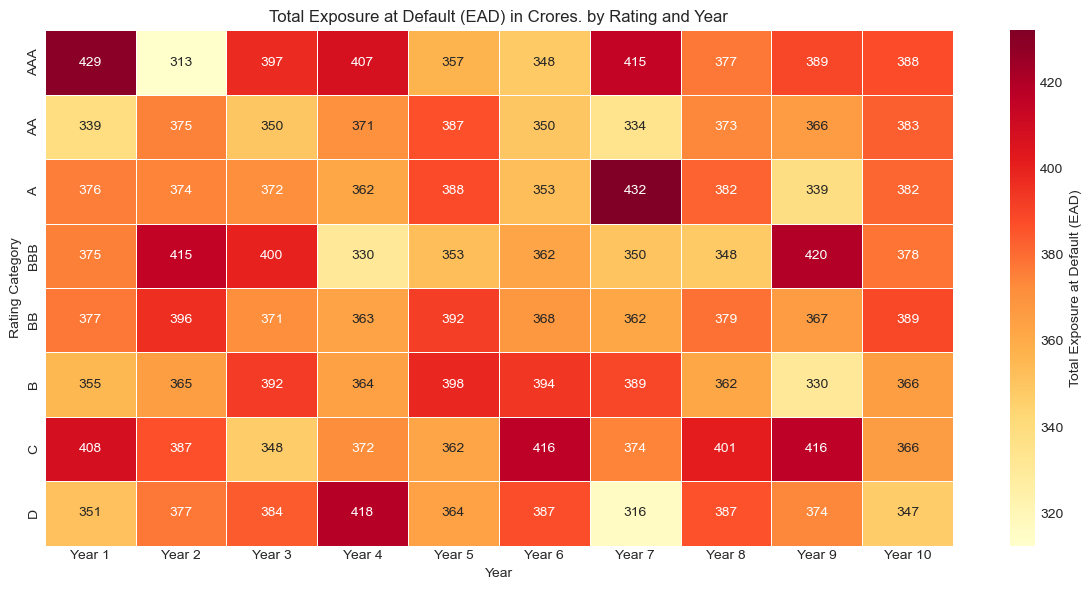

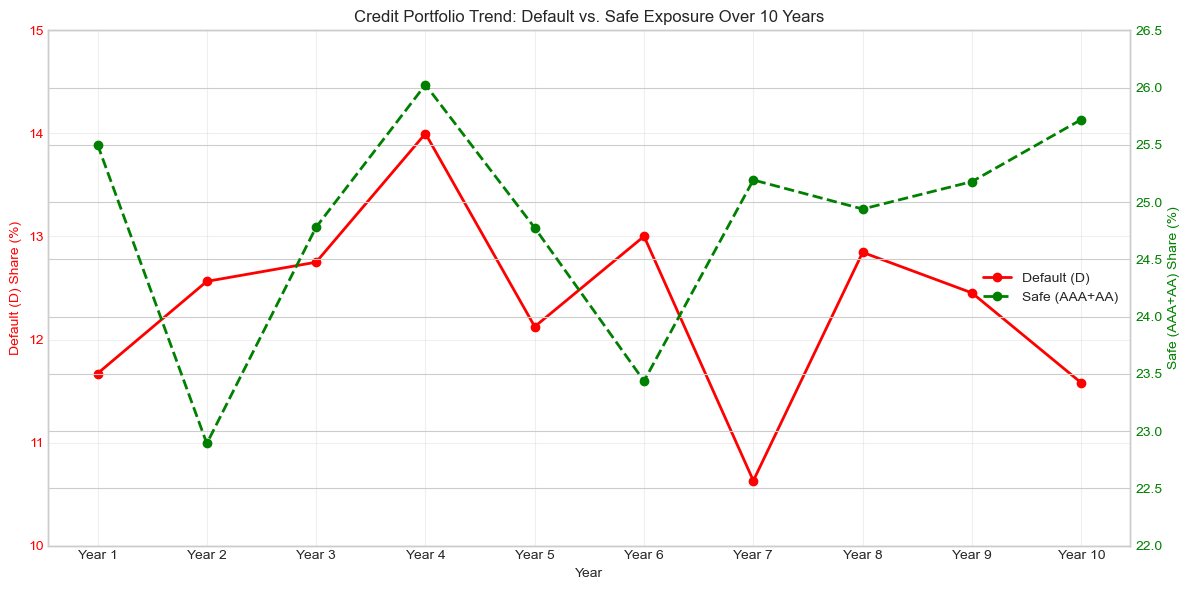

In [80]:
# Function to compute rating-wise exposure proportions for each year
def compute_rating_composition(
    df_ratings,
    df_exposure,
    year_labels,
    rating_order
):
    """
    Computes rating-wise exposure proportions for each year.

    Returns:
        composition_df: DataFrame
            index   -> year labels
            columns -> credit ratings
            values  -> exposure proportions
    """
    
    composition = []

    for year in year_labels:
        # ratings and exposure for one year
        ratings_y = df_ratings[year]
        exposure_y = df_exposure[year]

        # total exposure
        total_exposure = exposure_y.sum()

        # exposure by rating
        exposure_by_rating = (
            exposure_y
            .groupby(ratings_y)
            .sum()
            .reindex(rating_order, fill_value=0)
        )

        # convert to proportions
        proportions = exposure_by_rating / total_exposure
        
        # Append to the composition list
        composition.append(proportions)

    # build DataFrame with proper year index
    composition_df = pd.DataFrame(composition, index=year_labels)

    return composition_df

# Now, let's create the stacked area plot for Exposure-based composition over time.
# 1. Compute composition using the function
composition_df = compute_rating_composition(
    df_ratings=df_ratings,
    df_exposure=df_ead,          
    year_labels=YEAR_LABELS,
    rating_order=RATING_ORDER
)

# 2. Build color list in the SAME order
stack_colors = [RATING_COLORS[r] for r in RATING_ORDER]

# 3. Prepare data for stackplot
years = composition_df.index
stack_data = [composition_df[r] for r in RATING_ORDER]

# 4. Create figure (bigger = less clutter)
plt.figure(figsize=(12, 7))

# 5. Stacked area plot
plt.stackplot(
    years,
    stack_data,
    labels=RATING_ORDER,
    colors=stack_colors,
    alpha=0.9
)

# 6. Labels and title
plt.title('Portfolio Composition by Exposure (Time-Series)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Proportion of Total Exposure')

# 7. Legend the plot
plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    title='Credit Rating'
)

# 8. Layout adjustment so nothing overlaps
plt.tight_layout()
plt.show()

# Function to get exposure by rating for a specific year
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, year in zip(axes, ['Year 1', 'Year 10']):
    ratings_y = df_ratings[year]
    exposure_y = df_ead[year]
    exp_data = (
        exposure_y
        .groupby(ratings_y)
        .sum()
        .reindex(RATING_ORDER, fill_value=0)
    )

    ax.bar(
        exp_data.index,
        exp_data.values,
        color=[RATING_COLORS[r] for r in exp_data.index]
    )

    ax.set_title(f'Exposure by Credit Rating - {year}')
    ax.set_xlabel('Credit Rating')
    ax.set_ylabel('Total Exposure')


plt.tight_layout()
plt.show()

# Pie charts for Year 1 and Year 10
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, year in zip(axes, ['Year 1', 'Year 10']):
    # get rating-wise proportions for the year
    pie_data = composition_df.loc[year]

    ax.pie(
        pie_data.values,
        labels=pie_data.index,
        colors=[RATING_COLORS[r] for r in pie_data.index],
        autopct='%1.1f%%',
        startangle=90
    )

    ax.set_title(f'Portfolio Composition by Rating – {year}')

plt.tight_layout()
plt.show()

# Function to compute exposure-weighted migration matrix
def compute_exposure_weighted_migration_matrix(
    df_ratings,
    df_exposure,
    start_year,
    end_year,
    rating_order
):
    """
    Computes an exposure-weighted rating migration matrix.
    Rows = initial rating
    Columns = final rating
    """

    # Extract start & end ratings
    start_ratings = df_ratings[start_year]
    end_ratings = df_ratings[end_year]

    # Use exposure at start (standard assumption)
    exposure = df_exposure[start_year]

    # Build transition DataFrame
    transitions = pd.DataFrame({
        'start_rating': start_ratings,
        'end_rating': end_ratings,
        'exposure': exposure
    })

    # Aggregate exposure by (start, end)
    migration = (
        transitions
        .groupby(['start_rating', 'end_rating'])['exposure']  # sum exposures
        .sum()
        .unstack(fill_value=0)
        .reindex(index=rating_order, columns=rating_order, fill_value=0)
    )

    # Normalize row-wise (convert to probabilities)
    migration_matrix = migration.div(migration.sum(axis=1), axis=0)

    return migration_matrix

# Compute and plot the exposure-weighted migration matrix
migration_matrix = compute_exposure_weighted_migration_matrix(
    df_ratings=df_ratings,
    df_exposure=df_ead,        
    start_year='Year 1',
    end_year='Year 10',
    rating_order=RATING_ORDER
)

# Plotting the migration matrix as a heatmap
plt.figure(figsize=(10, 8))

# Create heatmap
ax = sns.heatmap(
    migration_matrix * 100,
    cmap='YlOrRd',
    annot=False,
    linewidths=0.5,
    cbar_kws={'label': 'Percentage of Exposure'}
)

# Manually add % labels
for i in range(migration_matrix.shape[0]):  # rows
    for j in range(migration_matrix.shape[1]):  # columns
        val = migration_matrix.iloc[i, j] * 100  # convert to %
        ax.text(j + 0.5, i + 0.5, f"{val:.1f}%",  # center align
                ha='center', va='center', color='black')

# Labels and title
plt.title('10-Year Exposure-Weighted Rating Migration Matrix')
plt.xlabel('Final Rating (Year 10)')
plt.ylabel('Initial Rating (Year 1)')

# Layout adjustment
plt.tight_layout()
plt.show()


# Portfolio Growth vs. Risk Quality Trend
# Define high-risk ratings
HIGH_RISK_RATINGS = ['BB', 'B', 'C', 'D']
# Compute total exposure per year
total_exposure = df_ead.sum(axis=0)
# Compute high-risk exposure share (%)
high_risk_share = []

for year in YEAR_LABELS:
    ratings_y = df_ratings[year]     # ratings in that year
    exposure_y = df_ead[year]        # exposure in that year

    total_exp = exposure_y.sum()
    
    # Compute high-risk exposure
    high_risk_exp = exposure_y[
        ratings_y.isin(HIGH_RISK_RATINGS)
    ].sum()
    # Compute share (%)
    high_risk_share.append((high_risk_exp / total_exp) * 100)

# Plot: Exposure (bars) + High-risk share (line)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bars: Total Exposure
ax1.bar(
    YEAR_LABELS,
    total_exposure,
    color='#cfd8e3',
    alpha=0.8,
    width=0.6,
    label='Total Exposure'
)

ax1.set_ylabel('Total Exposure (₹)')
ax1.set_xlabel('Year')
ax1.set_ylim(0, max(total_exposure) * 1.15)

# Line: High Risk Share
ax2 = ax1.twinx()
ax2.plot(
    YEAR_LABELS,
    high_risk_share,
    color='red',
    marker='o',
    linewidth=2.5,
    label='High Risk Share (%)'
)

ax2.set_ylabel('High Risk Share (%)', color='red')
ax2.set_ylim(0, 70)        
ax2.tick_params(axis='y', labelcolor='red')

# Title
plt.title('Portfolio Growth vs. Risk Quality Trend')

# Legend (combined from both axes)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='upper center',
    ncol=2
)

# Grid for readability
ax1.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# Heatmap of Borrower Count by Rating and Year

# Prepare data: count of borrowers by rating and year
borrower_counts = pd.DataFrame(index=RATING_ORDER)

# Fill the DataFrame with counts
for year in YEAR_LABELS:
    borrower_counts[year] = (
        df_ratings[year]
        .value_counts()  # count borrowers per rating
        .reindex(RATING_ORDER, fill_value=0)  # ensure all ratings are present
    )
# Plot heatmap
plt.figure(figsize=(12, 6))

# Create heatmap
sns.heatmap(
    borrower_counts,
    cmap='YlOrRd',                 # same color family
    annot=True,                    # numbers inside cells
    fmt='d',                       # integer counts
    linewidths=0.5,
    cbar_kws={'label': 'Number of Borrowers'}   # Adds a colourbar on right
)

# Add labels and title
plt.title('Heatmap of Borrower Count by Rating and Year')
plt.xlabel('Year')
plt.ylabel('Rating Category')


# Layout adjustment
plt.tight_layout()
plt.show()

# Total EAD per rating per year
ead_by_rating = pd.DataFrame(index=RATING_ORDER)

# Fill the DataFrame with total EAD
for year in YEAR_LABELS:
    ead_by_rating[year] = (
        df_ead[year]
        .groupby(df_ratings[year])  # exposure by rating
        .sum()
        .reindex(RATING_ORDER, fill_value=0)
    )

plt.figure(figsize=(12, 6))

# Create heatmap
sns.heatmap(
    ead_by_rating,
    cmap='YlOrRd',
    annot=True,
    fmt='.0f',
    linewidths=0.5,
    cbar_kws={'label': 'Total Exposure at Default (EAD)'}
)

# Add labels and title
plt.title('Total Exposure at Default (EAD) in Crores. by Rating and Year')
plt.xlabel('Year')
plt.ylabel('Rating Category')

# Layout adjustment
plt.tight_layout()
plt.show()


# Credit Portfolio Trend: Default vs. Safe Exposure Over 10 Years
DEFAULT_RATING = ['D']  # Define default rating
SAFE_RATINGS = ['AAA', 'AA']  # Define safe ratings

default_share = []         # to store default exposure share
safe_share = []            # to store safe exposure share

# Compute shares for each year
for year in YEAR_LABELS:
    ratings_y = df_ratings[year]
    exposure_y = df_ead[year]

    total_exp = exposure_y.sum()

    # Default exposure share
    default_exp = exposure_y[ratings_y.isin(DEFAULT_RATING)].sum()
    default_share.append((default_exp / total_exp) * 100)

    # Safe exposure share (AAA + AA)
    safe_exp = exposure_y[ratings_y.isin(SAFE_RATINGS)].sum() 
    safe_share.append((safe_exp / total_exp) * 100)
    
fig, ax1 = plt.subplots(figsize=(12, 6))

# Default share line (LEFT axis)
ax1.plot(
    YEAR_LABELS,
    default_share,
    color='red',
    marker='o',
    linewidth=2,
    label='Default (D)'
)

# Set labels and limits
ax1.set_ylabel('Default (D) Share (%)', color='red')
ax1.tick_params(axis='y', labelcolor='red')
ax1.set_ylim(10, 15)   # adjust if needed

# Safe share line (RIGHT axis)
ax2 = ax1.twinx()
ax2.plot(
    YEAR_LABELS,
    safe_share,
    color='green',
    linestyle='--',
    marker='o',
    linewidth=2,
    label='Safe (AAA+AA)'
)

# Set labels and limits
ax2.set_ylabel('Safe (AAA+AA) Share (%)', color='green')
ax2.tick_params(axis='y', labelcolor='green')
ax2.set_ylim(22, 26.5)  # adjust if needed

# Title and labels
ax1.set_xlabel('Year')
plt.title('Credit Portfolio Trend: Default vs. Safe Exposure Over 10 Years')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

# Grid for readability
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Key Modeling Assumptions

The analysis is based on the following assumptions:

1. Rating migrations follow a first-order Markov process, where next-year ratings depend only on current ratings.
2. Historical transition frequencies are representative of future migration behavior.
3. Defaults across borrowers are assumed independent.
4. Exposure at Default (EAD) and LGD are assumed constant within each year.
5. Portfolio-level metrics are calculated using exposure-weighted aggregation.
6. No macroeconomic feedback or borrower correlation effects are explicitly modeled.


### Transition Matrix


In [81]:

# exposure-weighted transition matrix
def compute_exposure_weighted_transition_matrix(
    df_ratings,
    df_exposure,
    year_start,
    year_end,
    rating_order
):
    """
    Exposure-weighted transition matrix from year_start to year_end.
    Rows    -> rating in year_start
    Columns -> rating in year_end
    """
    # Build transition DataFrame borrower wise
    transition_df = pd.DataFrame({
        'start_rating': df_ratings[year_start],
        'end_rating': df_ratings[year_end],
        'exposure': df_exposure[year_start]
    }).dropna()    # remove borrowers with missing ratings/exposure

    # Aggregate exposure by (start_rating, end_rating)
    exposure_flow = (
        transition_df
        .groupby(['start_rating', 'end_rating'])['exposure']
        .sum()  # sum of each start-end pair
        .unstack(fill_value=0)   # converts group data to matrix form
        .reindex(index=rating_order, columns=rating_order, fill_value=0)  # reindex to ensure all ratings are present
    )

    # Normalize row-wise to get transition probabilities
    row_totals = exposure_flow.sum(axis=1)  # computes sum of exposure in each rating
    row_totals[row_totals == 0] = 1  # if the summ comes to zero, set to 1 to avoid division by zero

    # divide each cell by the total of that row
    transition_matrix = exposure_flow.div(row_totals, axis=0)

    return transition_matrix  # output matrix


# Build matrices from Year 1 → Year 10

exposure_transition_matrices = {}

# Start index = 0  → Year 1
# End index   = 8  → Year 9
for i in range(0, len(YEAR_LABELS) - 1):
    year_start = YEAR_LABELS[i]       # Year 1 ... Year 9
    year_end = YEAR_LABELS[i + 1]     # Year 2 ... Year 10

    matrix_name = f"{year_start}_to_{year_end}"
    
    # calls function one by one for every year
    tm = compute_exposure_weighted_transition_matrix(
        df_ratings=df_ratings,
        df_exposure=df_ead,
        year_start=year_start,
        year_end=year_end,
        rating_order=RATING_ORDER
    )
    
    # stores the matrix in a dictionary
    exposure_transition_matrices[matrix_name] = tm
    print(f"Computed exposure-weighted transition matrix: {matrix_name}")



# display matrices as percentages
for name, matrix in exposure_transition_matrices.items():
    print(f"-- Transition Matrix: {name}--- ")
    print(matrix.to_string(float_format=lambda x: f"{x:.2%}"))


Computed exposure-weighted transition matrix: Year 1_to_Year 2
Computed exposure-weighted transition matrix: Year 2_to_Year 3
Computed exposure-weighted transition matrix: Year 3_to_Year 4
Computed exposure-weighted transition matrix: Year 4_to_Year 5
Computed exposure-weighted transition matrix: Year 5_to_Year 6
Computed exposure-weighted transition matrix: Year 6_to_Year 7
Computed exposure-weighted transition matrix: Year 7_to_Year 8
Computed exposure-weighted transition matrix: Year 8_to_Year 9
Computed exposure-weighted transition matrix: Year 9_to_Year 10
-- Transition Matrix: Year 1_to_Year 2--- 
end_rating      AAA     AA      A    BBB     BB      B      C      D
start_rating                                                        
AAA           9.39% 13.11% 10.85% 16.55% 17.66%  9.70%  9.86% 12.88%
AA            7.34% 10.70% 12.93% 15.39% 10.32% 10.41% 16.21% 16.71%
A            13.14% 13.72%  9.17% 10.69% 14.55% 12.56% 11.13% 15.03%
BBB          11.02% 11.91% 13.91% 12.33% 14.

### Probability of Default


--- Category-wise PD ---
start_rating    AAA     AA      A    BBB     BB      B      C      D
Year                                                                
Year 2       12.88% 16.71% 15.03% 13.35% 12.98% 12.93%  9.58% 11.34%
Year 3        8.64% 11.85% 16.26% 14.22% 14.61% 12.80% 11.93% 11.73%
Year 4       13.91% 15.70% 16.53% 13.67% 14.10% 10.68% 14.20% 11.79%
Year 5       14.29%  9.19%  8.79% 11.13% 14.42% 14.37% 11.53% 14.12%
Year 6       10.36% 11.05% 11.36% 11.11% 11.69% 13.42% 14.56% 15.05%
Year 7       12.88% 10.03% 14.33% 11.37% 10.40%  7.96% 11.08%  8.22%
Year 8       14.21% 15.51% 12.69% 13.74% 11.39% 12.81% 15.29%  9.05%
Year 9       13.89% 12.95% 13.74%  8.31% 14.52% 10.41% 12.48% 12.48%
Year 10      12.78% 12.45%  9.90% 13.20%  9.10%  9.70% 13.68% 11.12%

--- Portfolio PD ---
Year
Year 2    13.03%
Year 3    12.87%
Year 4    13.77%
Year 5    12.30%
Year 6    12.32%
Year 7    10.72%
Year 8    13.14%
Year 9    12.40%
Year 10   11.60%


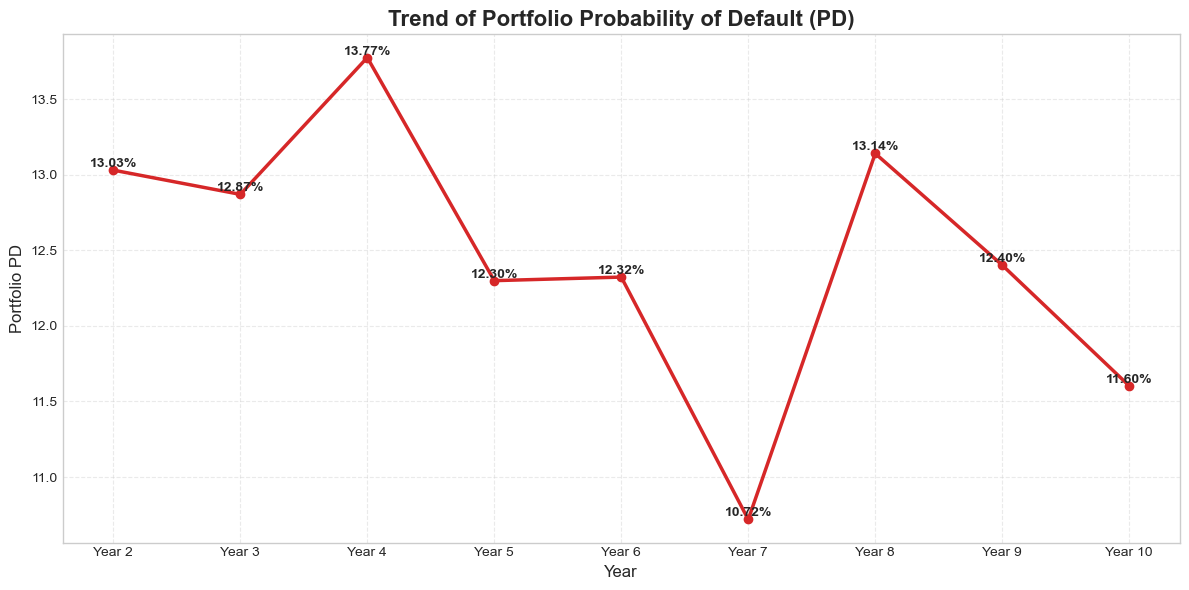

In [82]:
# Calculate Category-wise PD and Portfolio PD over 10 Years
pd_by_rating_results = {}
portfolio_pd_results = {}

# Loop only Year 2 → Year 10
for i in range(0, len(YEAR_LABELS)-1):  # 0 to 8
    prev_year = YEAR_LABELS[i]     # Year 1 ... Year 9
    curr_year = YEAR_LABELS[i + 1]         # Year 2 ... Year 10

    matrix_name = f"{prev_year}_to_{curr_year}"   # get matrix name
    tm = exposure_transition_matrices[matrix_name]  # get the matrix

    # Category-wise PD
    pd_by_rating = tm['D']   # Series indexed by rating
    pd_by_rating_results[curr_year] = pd_by_rating  # store results of pd_by_rating

    # Portfolio PD (exposure-weighted)
    exposure_prev = df_ead[prev_year]   # exposure in previous year
    ratings_prev = df_ratings[prev_year]     # ratings in previous year

    exposure_by_rating = (
        exposure_prev        # exposure in previous year
        .groupby(ratings_prev)  # group by ratings
        .sum()  # sum of exposure by rating
        .reindex(RATING_ORDER, fill_value=0)
    )

    total_exposure = exposure_by_rating.sum()

    # calculate portfolio PD
    if total_exposure > 0:
        weights = exposure_by_rating / total_exposure
        portfolio_pd = (weights * pd_by_rating).sum()
    else:
        portfolio_pd = 0

    portfolio_pd_results[curr_year] = portfolio_pd

# Display Category-wise PD and Portfolio PD
pd_rating_df = pd.DataFrame(pd_by_rating_results).T
pd_rating_df.index.name = 'Year'

print("\n--- Category-wise PD ---")
print(pd_rating_df.to_string(float_format=lambda x: f"{x:.2%}"))

portfolio_pd_series = pd.Series(portfolio_pd_results, name='Portfolio PD')
portfolio_pd_series.index.name = 'Year'

print("\n--- Portfolio PD ---")
print(portfolio_pd_series.to_string(float_format=lambda x: f"{x:.2%}"))


# Extract years and PD values
years = portfolio_pd_series.index
pd_values = portfolio_pd_series.values * 100  # convert to %

# plotting the Portfolio PD trend
plt.figure(figsize=(12, 6))

# Line plot
plt.plot(
    years,
    pd_values,
    color='#d62728',        # red line
    marker='o',
    linewidth=2.5
)

# Annotate each point with value
for x, y in zip(years, pd_values):
    plt.text(
        x, y,
        f"{y:.2f}%",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# Labels and title
plt.title('Trend of Portfolio Probability of Default (PD)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Portfolio PD', fontsize=12)

# Grid (light, like reference)
plt.grid(True, linestyle='--', alpha=0.4)

# Tight layout
plt.tight_layout()
plt.show()


## CALCULATING EL


--- Monetary EAD (INR Crores) ---
rating        AAA        AA         A       BBB        BB         B         C         D
Year 2   Rs 6,338  Rs 5,409  Rs 5,621  Rs 5,663  Rs 5,970  Rs 5,490  Rs 5,985  Rs 5,230
Year 3   Rs 4,667  Rs 5,445  Rs 5,818  Rs 6,226  Rs 6,253  Rs 5,259  Rs 5,958  Rs 5,473
Year 4   Rs 6,126  Rs 5,421  Rs 5,760  Rs 6,175  Rs 5,767  Rs 6,076  Rs 5,168  Rs 6,092
Year 5   Rs 6,104  Rs 5,669  Rs 5,504  Rs 5,003  Rs 5,270  Rs 5,470  Rs 5,551  Rs 6,533
Year 6   Rs 5,378  Rs 6,447  Rs 5,952  Rs 5,403  Rs 5,620  Rs 6,400  Rs 5,395  Rs 5,541
Year 7   Rs 5,311  Rs 5,162  Rs 5,228  Rs 5,492  Rs 5,822  Rs 5,900  Rs 6,217  Rs 5,683
Year 8   Rs 5,762  Rs 4,775  Rs 6,344  Rs 5,383  Rs 5,967  Rs 5,548  Rs 6,008  Rs 4,793
Year 9   Rs 5,414  Rs 5,949  Rs 5,928  Rs 5,371  Rs 5,588  Rs 5,474  Rs 6,540  Rs 5,755
Year 10  Rs 5,833  Rs 5,731  Rs 5,126  Rs 6,546  Rs 5,229  Rs 5,047  Rs 6,480  Rs 5,659

--- LGD (Exposure-weighted) ---
rating      AAA      AA       A     BBB      BB     

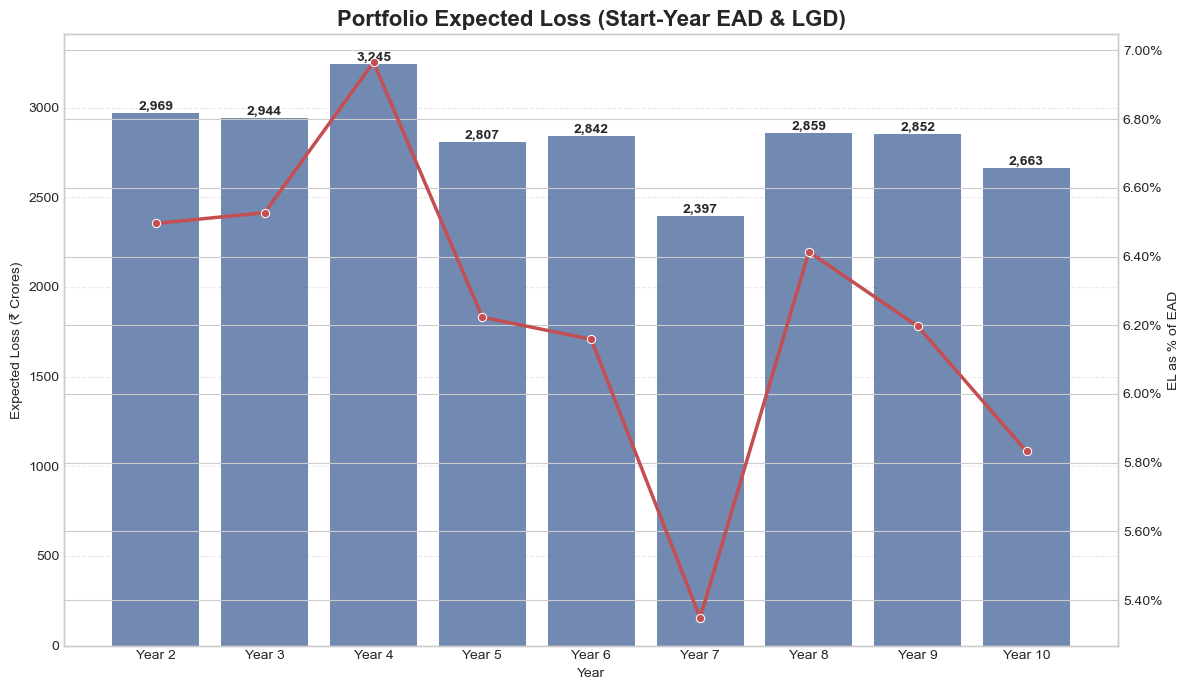

In [83]:
# define a function to normalise the lgd values bw 0-1
def normalize_lgd(series):
    s = pd.to_numeric(series, errors='coerce').fillna(0).astype(float) # convert to numeric, coerce errors to NaN, fill NaN with 0, convert to float
    return s / 100 if s.max() > 1 else s  # if max > 1, divide by 100 to normalise

# containers for final tables
monetary_ead_tbl = {}
lgd_tbl = {}
lgd_ead_tbl = {}
el_tbl = {}
portfolio_rows = []

for i in range(len(YEAR_LABELS) - 1):  # year 1 to year 9

    start_year = YEAR_LABELS[i]   # Year 1 ... Year 9
    end_year = YEAR_LABELS[i + 1]  # Year 2 ... Year 10

    # PD from transition matrix
    tm = exposure_transition_matrices[f"{start_year}_to_{end_year}"]
    pd_by_rating = tm['D']

    # Start-year data
    ratings = df_ratings[start_year]
    amount = pd.to_numeric(df_Amount[start_year], errors='coerce').fillna(0)   # amount in Rs Crores
    ead_factor = pd.to_numeric(df_ead[start_year], errors='coerce').fillna(0)
    

    # Monetary exposure
    monetary_ead = amount * ead_factor
    # Map rating-level LGD to borrowers
    # lgd_by_rating = normalize_lgd(df_lgd.iloc[0])
    # lgd_raw = ratings.map(lgd_by_rating).fillna(0)
    lgd_raw = normalize_lgd(df_lgd[start_year])

    # each row is one borrower with rating, monetary ead, lgd
    df_tmp = pd.DataFrame({
        'rating': ratings,
        'monetary_ead': monetary_ead,
        'lgd': lgd_raw    
    })
    
    # Getting the product of ead and lgd
    df_tmp['lgd_x_ead'] = df_tmp['lgd'] * df_tmp['monetary_ead']
    grp = df_tmp.groupby('rating')    # now rating is categorised rating wise
    
    # sums monetary ead of all borrowers in that rating
    rating_monetary_ead = grp['monetary_ead'].sum()
    
    # Exposure-weighted LGD
    rating_lgd = (
    grp['lgd_x_ead'].sum()
    / rating_monetary_ead
    )
    
    # Expected Loss calculations
    rating_lgd_ead = rating_lgd * rating_monetary_ead
    rating_el = pd_by_rating * rating_lgd_ead

    # Reindex
    rating_monetary_ead = rating_monetary_ead.reindex(RATING_ORDER, fill_value=0)
    rating_lgd = rating_lgd.reindex(RATING_ORDER, fill_value=0)
    rating_lgd_ead = rating_lgd_ead.reindex(RATING_ORDER, fill_value=0)
    rating_el = rating_el.reindex(RATING_ORDER, fill_value=0)

    # Storing year wise results
    monetary_ead_tbl[end_year] = rating_monetary_ead
    lgd_tbl[end_year] = rating_lgd
    lgd_ead_tbl[end_year] = rating_lgd_ead
    el_tbl[end_year] = rating_el

    # Portfolio EL
    total_ead = rating_monetary_ead.sum()
    total_el = rating_el.sum()
    
    # makes a table for portfolio
    portfolio_rows.append({
        "Year": end_year,
        "Total_EAD": total_ead,
        "Portfolio_EL": total_el,
        "EL_%_of_EAD": total_el / total_ead if total_ead > 0 else 0
    })


# Final Tables
df_monetary_ead = pd.DataFrame(monetary_ead_tbl).T
df_lgd = pd.DataFrame(lgd_tbl).T
df_lgd_ead = pd.DataFrame(lgd_ead_tbl).T
df_el = pd.DataFrame(el_tbl).T
df_portfolio = pd.DataFrame(portfolio_rows).set_index("Year")


# Formatting so that becomes presentable 
def format_rs(df):
    return df.applymap(lambda x: f"Rs {x:,.0f}")  

# Display the final tables
print("\n--- Monetary EAD (INR Crores) ---")
print(format_rs(df_monetary_ead).to_string())

print("\n--- LGD (Exposure-weighted) ---")
print(df_lgd.applymap(lambda x: f"{x:.2%}").to_string())

# LGD × Monetary EAD
print("\n--- LGD × Monetary EAD (INR Crores) ---")
print(format_rs(df_lgd_ead).to_string())

# Expected Loss by Rating
print("\n--- Expected Loss (EL) by Rating (INR Crores) ---")
print(format_rs(df_el).to_string())

# Portfolio Expected Loss
print("\n Portfolio Expected Loss")
df_portfolio_print = df_portfolio.copy()
df_portfolio_print['Total_EAD'] = df_portfolio_print['Total_EAD'].apply(lambda x: f"Rs {x:,.0f}")
df_portfolio_print['Portfolio_EL'] = df_portfolio_print['Portfolio_EL'].apply(lambda x: f"Rs {x:,.0f}")
df_portfolio_print['EL_%_of_EAD'] = df_portfolio_print['EL_%_of_EAD'].apply(lambda x: f"{x:.2%}")
print(df_portfolio_print.to_string())

# plot portfolio EL trend
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    x=df_portfolio.index,
    y=df_portfolio['Portfolio_EL'],
    color='#4c72b0',
    alpha=0.85
)

for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width()/2,
        p.get_height(),
        f"{p.get_height():,.0f}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

ax2 = ax.twinx()
sns.lineplot(
    x=df_portfolio.index,
    y=df_portfolio['EL_%_of_EAD'],
    color="#c44e52",
    marker='o',
    linewidth=2.5,
    ax=ax2
)

ax.set_title('Portfolio Expected Loss (Start-Year EAD & LGD)', fontsize=16, fontweight='bold')
ax.set_ylabel('Expected Loss (₹ Crores)')
ax2.set_ylabel('EL as % of EAD')

ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()



### CUMILATIVE PD FOR PORTFOLIO


 Rating-wise Cumulative PD 
     CPD_5Y CPD_10Y
AAA  41.27%  70.45%
AA   43.79%  71.04%
A    45.83%  72.08%
BBB  42.98%  69.16%
BB   45.37%  70.24%
B    41.93%  67.36%
C    39.55%  70.61%
D    40.71%  67.30%

--- Portfolio Cumulative PD ---
5-Year Portfolio CPD :  42.63%
10-Year Portfolio CPD:  69.82%


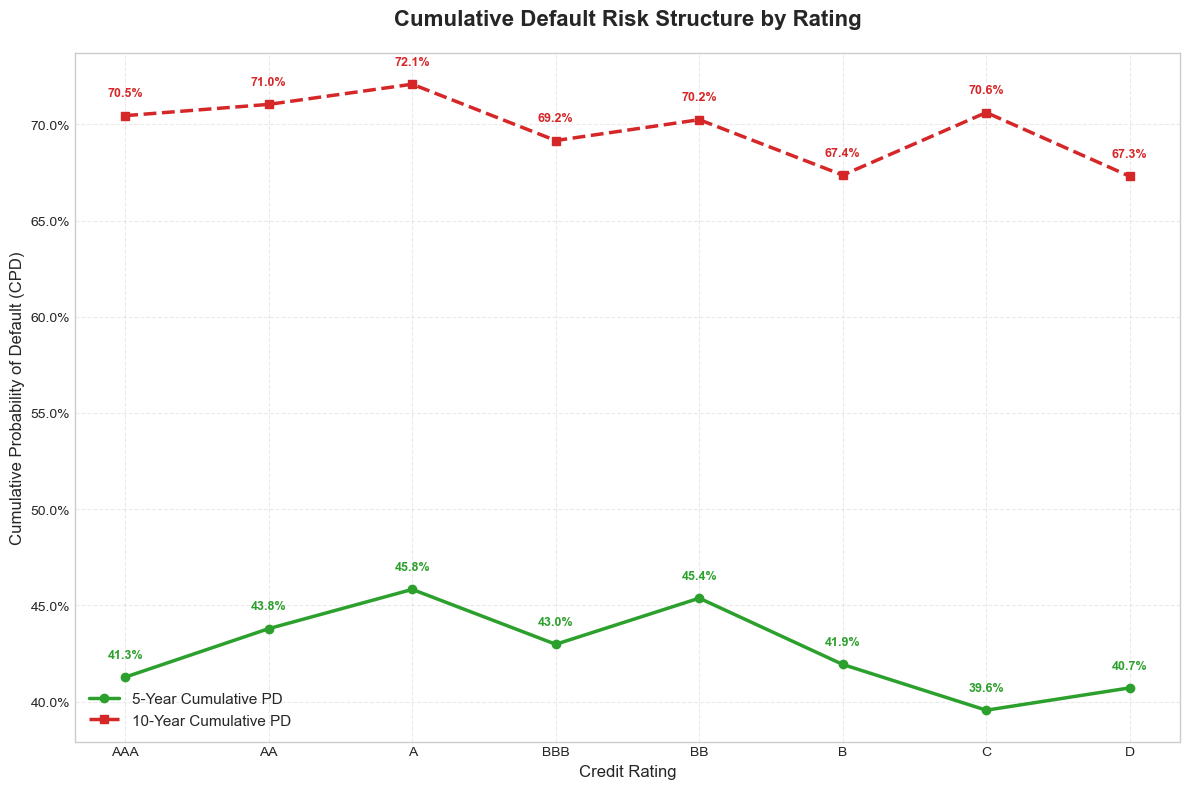

In [84]:
# concept: For each rating, cumulative PD is calculated by compounding yearly survival probabilities. Portfolio cumulative PD is then obtained as an exposure-weighted average of rating-level cumulative PDs using initial-year exposure weights.

# Compute Rating-wise Cumulative PD


cpd_5y_by_rating = {}  #dictionary to hold 5-year CPD
cpd_10y_by_rating = {}  #dictionary to hold 10-year CPD

for rating in RATING_ORDER:

    # 5-Year cumulative PD (Years 2–5)
    # getting year wise pd for every rating
    pd_5y = pd_rating_df.loc[['Year 2', 'Year 3', 'Year 4', 'Year 5'], rating]
    # calculating survival probability for 5 years
    survival_5y = (1 - pd_5y).prod()
    # storing the cumulative pd rating wise 
    cpd_5y_by_rating[rating] = 1 - survival_5y

    # 10-Year cumulative PD (Years 2–10)
    # getting all year wise pd for every rating
    pd_10y = pd_rating_df.loc[:, rating]
    # calculating survival probability for 10 years
    survival_10y = (1 - pd_10y).prod()
    # storing the cumulative pd rating wise
    cpd_10y_by_rating[rating] = 1 - survival_10y

# Build DataFrame for Rating-wise Cumulative PD with index as ratings and columns as CPD_5Y and CPD_10Y
df_cpd_rating = pd.DataFrame({
    'CPD_5Y': pd.Series(cpd_5y_by_rating),
    'CPD_10Y': pd.Series(cpd_10y_by_rating)
})

print("\n Rating-wise Cumulative PD ")
print(df_cpd_rating.applymap(lambda x: f"{x:.2%}").to_string())   # for formatting


# Compute Portfolio Weights (Year 1 Exposure)

# getting ead and ratings for year 1
ead_y1 = pd.to_numeric(df_ead['Year 1'], errors='coerce').fillna(0)
ratings_y1 = df_ratings['Year 1']

# total 1 year  exposure by rating
ead_by_rating_y1 = (
    ead_y1
    .groupby(ratings_y1)
    .sum()
    .reindex(RATING_ORDER, fill_value=0)
)

total_ead_y1 = ead_by_rating_y1.sum()
weights_y1 = ead_by_rating_y1 / total_ead_y1


# Portfolio Cumulative PD

portfolio_cpd_5y = (df_cpd_rating['CPD_5Y'] * weights_y1).sum()
portfolio_cpd_10y = (df_cpd_rating['CPD_10Y'] * weights_y1).sum()

print("\n--- Portfolio Cumulative PD ---")
print(f"5-Year Portfolio CPD :  {portfolio_cpd_5y:.2%}")
print(f"10-Year Portfolio CPD:  {portfolio_cpd_10y:.2%}")


# Trendline Comparison Plot

plt.figure(figsize=(12, 8))

# 5-Year cumulative PD line
plt.plot(
    df_cpd_rating.index,
    df_cpd_rating['CPD_5Y'],
    marker='o',
    linewidth=2.5,
    color='#2ca02c',
    label='5-Year Cumulative PD'
)

# 10-Year cumulative PD line
plt.plot(
    df_cpd_rating.index,
    df_cpd_rating['CPD_10Y'],
    marker='s',
    linewidth=2.5,
    linestyle='--',
    color='#d62728',
    label='10-Year Cumulative PD'
)

# Titles & labels
plt.title(
    'Cumulative Default Risk Structure by Rating',
    fontsize=16,
    fontweight='bold',
    pad=20
)
plt.xlabel('Credit Rating', fontsize=12)
plt.ylabel('Cumulative Probability of Default (CPD)', fontsize=12)

# Y-axis in %
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Grid
plt.grid(True, linestyle='--', alpha=0.4)

# Data labels
for i, rating in enumerate(df_cpd_rating.index):
    y5 = df_cpd_rating.loc[rating, 'CPD_5Y']
    y10 = df_cpd_rating.loc[rating, 'CPD_10Y']

    plt.text(i, y5 + 0.01, f"{y5:.1%}",
             ha='center', fontsize=9, color='#2ca02c', fontweight='bold')

    plt.text(i, y10 + 0.01, f"{y10:.1%}",
             ha='center', fontsize=9, color='#d62728', fontweight='bold')

# Legend
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()


## STRESSED EL


 LGD Stress Test Results
        Normal_EL Stressed_EL Difference Pct_Increase
Year                                                 
Year 2   Rs 2,969    Rs 4,394   Rs 1,425       48.00%
Year 3   Rs 2,887    Rs 4,301   Rs 1,415       49.00%
Year 4   Rs 3,186    Rs 4,555   Rs 1,370       43.00%
Year 5   Rs 2,770    Rs 3,490     Rs 720       26.00%
Year 6   Rs 2,825    Rs 4,068   Rs 1,243       44.00%
Year 7   Rs 2,386    Rs 3,316     Rs 930       39.00%
Year 8   Rs 2,902    Rs 3,570     Rs 668       23.00%
Year 9   Rs 2,823    Rs 4,206   Rs 1,383       49.00%
Year 10  Rs 2,644    Rs 3,490     Rs 846       32.00%


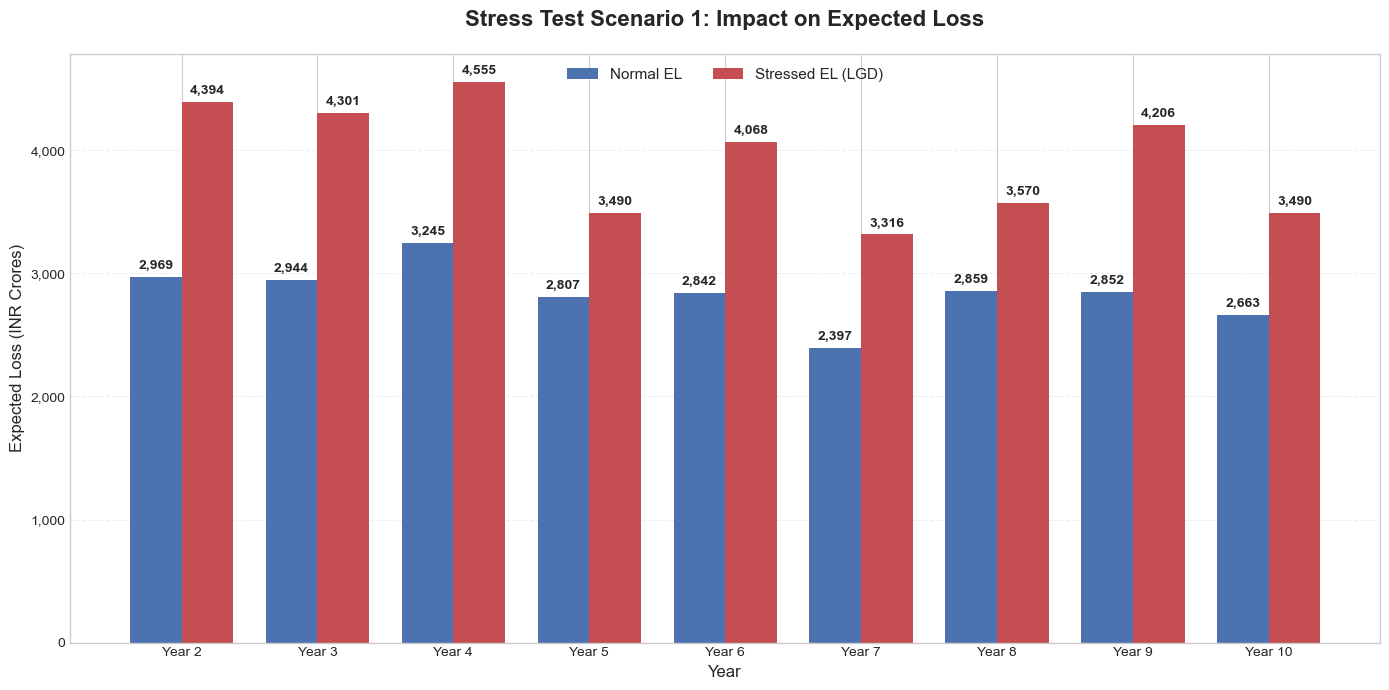

In [85]:
# These factors multiply the original LGD to simulate a downturn.

lgd_stress_factors = {
    'Year 1': 1.48, 'Year 2': 1.49, 'Year 3': 1.43, 'Year 4': 1.26, 'Year 5': 1.44,
    'Year 6': 1.39, 'Year 7': 1.23, 'Year 8': 1.49, 'Year 9': 1.32, 'Year 10': 1.34
}

#guarnatees lgd values between 0 and 1
def normalize_lgd(series):
    s = pd.to_numeric(series, errors='coerce').fillna(0).astype(float)
    return s / 100 if s.max() > 1 else s

# Normalize LGD values
normal_el_rows = []
# container for stressed el rows
stressed_el_rows = []

# Loop through years
for i in range(len(YEAR_LABELS) - 1):

    start_year = YEAR_LABELS[i]        # e.g. Year 1 to year 9
    end_year = YEAR_LABELS[i + 1]      # e.g. Year 2 to year 10

    # PD (from transition matrix)
    pd_by_rating = pd_rating_df.loc[end_year]

    # Start-year data
    ratings = df_ratings[start_year]   # borrower ratings at start year
    amount = pd.to_numeric(df_Amount[start_year], errors='coerce').fillna(0)    # amount in Rs Crores
    ead_factor = pd.to_numeric(df_ead[start_year], errors='coerce').fillna(0)   # ead factor
    # LGD values is assigned to each borrower based on their rating
    lgd_raw = ratings.map(df_lgd.iloc[0])


    # Monetary EAD
    monetary_ead = amount * ead_factor

    # Apply LGD stress
    stress_factor = lgd_stress_factors[start_year]
    # ensures lgd values are between 0 and 1 after stress
    lgd_stressed = np.clip(lgd_raw * stress_factor, 0, 1)
    
    # Temporary DataFrame for calculations
    df_tmp = pd.DataFrame({
        'rating': ratings,
        'monetary_ead': monetary_ead,
        'lgd': lgd_raw,
        'lgd_stressed': lgd_stressed
    })
    
    # LGD × EAD
    df_tmp['lgd_x_ead'] = df_tmp['lgd'] * df_tmp['monetary_ead']
    df_tmp['lgd_stressed_x_ead'] = df_tmp['lgd_stressed'] * df_tmp['monetary_ead']
    
    # Group by rating
    grp = df_tmp.groupby('rating')

    # total exposure by rating
    rating_ead = grp['monetary_ead'].sum().reindex(RATING_ORDER, fill_value=0)
    
    # Exposure-weighted LGD rating wise
    lgd_weighted = (
    grp['lgd_x_ead'].sum()
    / rating_ead
    ).reindex(RATING_ORDER, fill_value=0)
    
    # Exposure-weighted Stressed LGD rating wise
    lgd_stressed_weighted = (
    grp['lgd_stressed_x_ead'].sum()
    / rating_ead
    ).reindex(RATING_ORDER, fill_value=0)

    # LGD × EAD
    lgd_ead = lgd_weighted * rating_ead
    lgd_ead_stressed = lgd_stressed_weighted * rating_ead

    # Expected Loss calculations
    normal_el = (pd_by_rating * lgd_ead).sum()
    stressed_el = (pd_by_rating * lgd_ead_stressed).sum()
    
    # Store results
    normal_el_rows.append({
        "Year": end_year,
        "Normal_EL": normal_el
    })

    stressed_el_rows.append({
        "Year": end_year,
        "Stressed_EL": stressed_el
    })

# Create DataFrames from results
df_normal_el = pd.DataFrame(normal_el_rows).set_index("Year")
df_stressed_el = pd.DataFrame(stressed_el_rows).set_index("Year")

# Combine results and calculate differences
df_stress_result = df_normal_el.join(df_stressed_el)
df_stress_result['Difference'] = df_stress_result['Stressed_EL'] - df_stress_result['Normal_EL']
df_stress_result['Pct_Increase'] = df_stress_result['Difference'] / df_stress_result['Normal_EL']

print("\n LGD Stress Test Results")
df_print = df_stress_result.copy()
df_print['Normal_EL'] = df_print['Normal_EL'].apply(lambda x: f"Rs {x:,.0f}")
df_print['Stressed_EL'] = df_print['Stressed_EL'].apply(lambda x: f"Rs {x:,.0f}")
df_print['Difference'] = df_print['Difference'].apply(lambda x: f"Rs {x:,.0f}")
df_print['Pct_Increase'] = df_print['Pct_Increase'].apply(lambda x: f"{x:.2%}")

print(df_print.to_string())

# Bar Chart: Normal EL vs. Stressed EL
comparison_df = pd.DataFrame({
    'Normal_EL': df_portfolio['Portfolio_EL'],
    'Stressed_EL': df_stressed_el['Stressed_EL']
})

# Calculate Difference and Percentage Increase
comparison_df['Difference'] = (
    comparison_df['Stressed_EL'] - comparison_df['Normal_EL']
)
comparison_df['Pct_Increase'] = (
    comparison_df['Difference'] / comparison_df['Normal_EL']
)

# Data
years = comparison_df.index.tolist()
normal_el = comparison_df['Normal_EL'].values
stressed_el = comparison_df['Stressed_EL'].values

x = np.arange(len(years))
width = 0.38

plt.figure(figsize=(14, 7))

# Bars
bars1 = plt.bar(
    x - width/2,
    normal_el,
    width,
    label='Normal EL',
    color='#4c72b0'
)

bars2 = plt.bar(
    x + width/2,
    stressed_el,
    width,
    label='Stressed EL (LGD)',
    color='#c44e52'
)

# Labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 40,
            f"{height:,.0f}",
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )

# Axes & titles
plt.xticks(x, years)
plt.ylabel('Expected Loss (INR Crores)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.title(
    'Stress Test Scenario 1: Impact on Expected Loss',
    fontsize=16,
    fontweight='bold',
    pad=20
)

# Y-axis formatting
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))  # thousands separator
plt.grid(axis='y', linestyle='--', alpha=0.35)

# Legend
plt.legend(frameon=False, fontsize=11, loc='upper center', ncol=2)

plt.tight_layout()
plt.show()



 Stress Test Scenario 2: Rating Slip Impact (Year 10)
Normal EL (Year 10):   Rs 2,663
Stressed EL (Slip):    Rs 2,554
Increase in EL:        Rs -109
Percent Increase:     -4.1%


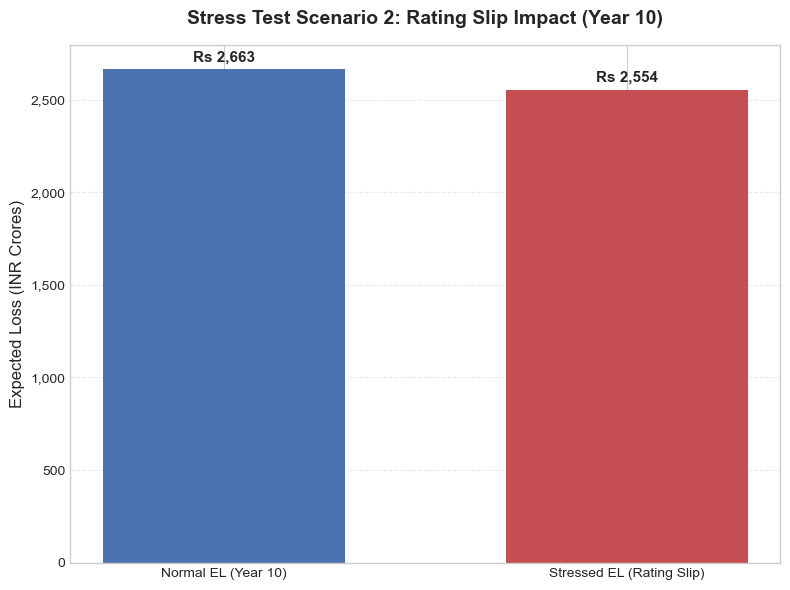

In [86]:
print("\n Stress Test Scenario 2: Rating Slip Impact (Year 10)")


# Rating Slip Map
rating_slip_map = {
    'AAA': 'A',
    'AA': 'A',
    'A': 'B',
    'BBB': 'C',
    'BB': 'C',
    'B': 'D',
    'C': 'C',
    'D': 'D'
}

# Normalize LGD
def norm_lgd(series):
    s = pd.to_numeric(series, errors='coerce').fillna(0).astype(float)
    return s / 100 if s.max() > 1 else s

# Create stressed Year-10 ratings
original_y9_ratings = df_ratings['Year 9']
stressed_y10_ratings = original_y9_ratings.map(rating_slip_map).fillna('D')

# Get original Year-10 inputs
year = 'Year 10'

# getting pd by rating for year 10
pd_by_rating = pd_rating_df.loc[year]
lgd_raw = norm_lgd(df_lgd.iloc[0])              # rating-level LGD
ead_factor = pd.to_numeric(df_ead[year], errors='coerce').fillna(0)
amount = pd.to_numeric(df_Amount[year], errors='coerce').fillna(0)

# Monetary EAD
monetary_ead = amount * ead_factor

# Map LGD to borrowers
lgd_borrower = stressed_y10_ratings.map(lgd_raw)

# Potential loss
lgd_x_ead = lgd_borrower * monetary_ead

# Aggregate using STRESSED ratings
df_tmp = pd.DataFrame({
    'rating': stressed_y10_ratings,
    'lgd_x_ead': lgd_x_ead
})

lgd_ead_by_rating_stressed = (
    df_tmp
    .groupby('rating')['lgd_x_ead']
    .sum()
    .reindex(RATING_ORDER, fill_value=0)
)

# Stressed EL
el_by_rating_stressed = pd_by_rating * lgd_ead_by_rating_stressed
portfolio_el_stressed = el_by_rating_stressed.sum()

# Normal EL (from earlier results)
normal_el_y10 = df_portfolio.loc['Year 10', 'Portfolio_EL']

difference = portfolio_el_stressed - normal_el_y10
pct_increase = difference / normal_el_y10

# Print Results
print(f"Normal EL (Year 10):   Rs {normal_el_y10:,.0f}")
print(f"Stressed EL (Slip):    Rs {portfolio_el_stressed:,.0f}")
print(f"Increase in EL:        Rs {difference:,.0f}")
print(f"Percent Increase:     {pct_increase:+.1%}")

# Visualization
plt.figure(figsize=(8, 6))

categories = ['Normal EL (Year 10)', 'Stressed EL (Rating Slip)']
values = [normal_el_y10, portfolio_el_stressed]
colors = ['#4c72b0', '#c44e52']

bars = plt.bar(categories, values, color=colors, width=0.6)

plt.title(
    'Stress Test Scenario 2: Rating Slip Impact (Year 10)',
    fontsize=14, fontweight='bold', pad=15
)
plt.ylabel('Expected Loss (INR Crores)', fontsize=12)

plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.grid(axis='y', linestyle='--', alpha=0.4)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + max(values)*0.01,
        f'Rs {height:,.0f}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()


## Risk Analysis


 Rating Stability Analysis

Average Yearly Stability (Probability of staying in same rating):

AAA   13.64%
BB    12.47%
C     12.36%
AA    12.32%
A     11.97%
BBB   11.77%
B     11.66%
D     11.66%

Conclusion: The most stable rating category is 'AAA' with an average yearly stability of 13.64%.


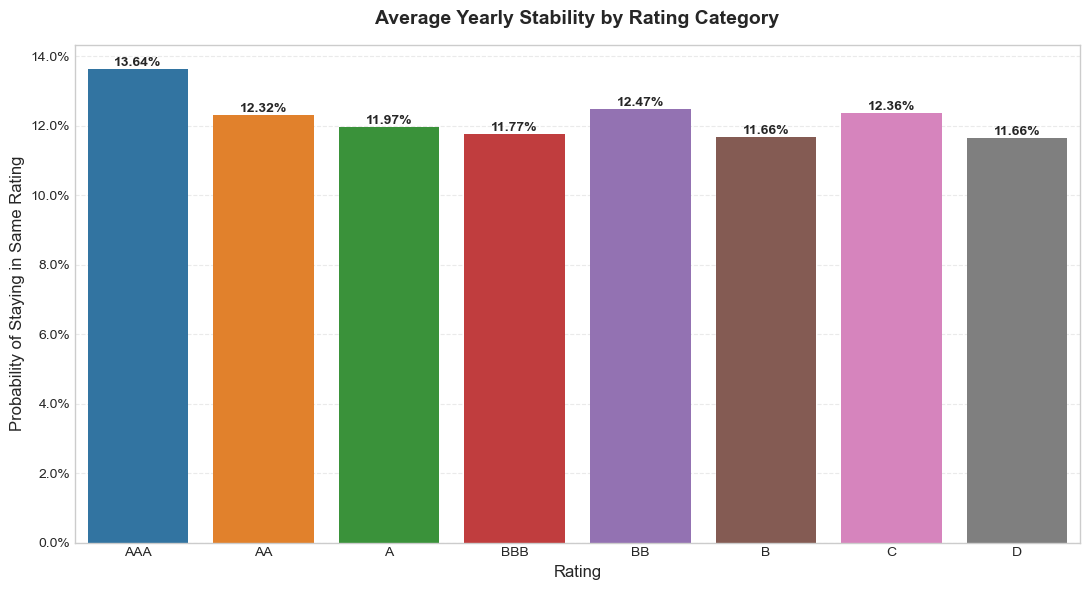

In [87]:

print("\n Rating Stability Analysis")

# Extract diagonal (stability) from each transition matrix

diagonals_list = []

for matrix_name, tm in exposure_transition_matrices.items():
    # Diagonal = probability of staying in same rating
    diagonal_probs = pd.Series(
        np.diag(tm),
        index=RATING_ORDER,
        name=matrix_name
    )
    diagonals_list.append(diagonal_probs)

# Combine diagonals across years

diagonals_df = pd.concat(diagonals_list, axis=1)

# Average stability across all years

average_stability = diagonals_df.mean(axis=1)
average_stability.name = "Average_Stability"

# Identify most stable rating
most_stable_rating = average_stability.idxmax()
highest_stability_value = average_stability.max()

# Print results
print("\nAverage Yearly Stability (Probability of staying in same rating):\n")
print(
    average_stability
    .sort_values(ascending=False)
    .to_string(float_format=lambda x: f"{x:.2%}")
)

print(
    f"\nConclusion: The most stable rating category is '{most_stable_rating}' "
    f"with an average yearly stability of {highest_stability_value:.2%}."
)

# Visualization – Stability Bar Chart

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    x=average_stability.index,
    y=average_stability.values,
    palette='tab10'
)

plt.title(
    'Average Yearly Stability by Rating Category',
    fontsize=14,
    fontweight='bold',
    pad=15
)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Probability of Staying in Same Rating', fontsize=12)

# Format y-axis as %
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Add value labels on bars
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(
        f"{height:.2%}",
        (bar.get_x() + bar.get_width() / 2, height),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('Rating_Stability_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()



 INDICATOR 1: Portfolio PD Monitoring 
         Portfolio_PD  YoY_Change_PD
Year                                
Year 2         13.03%              -
Year 3         12.87%         -0.16%
Year 4         13.77%          0.90%
Year 5         12.30%         -1.48%
Year 6         12.32%          0.02%
Year 7         10.72%         -1.60%
Year 8         13.14%          2.42%
Year 9         12.40%         -0.74%
Year 10        11.60%         -0.80%


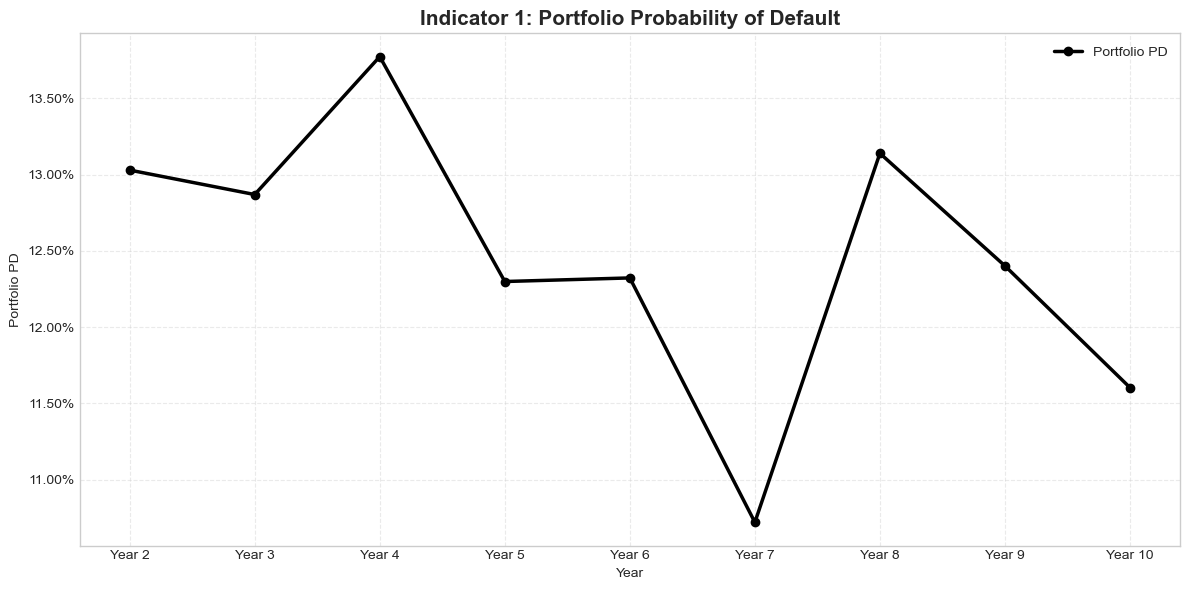

In [88]:
print("\n INDICATOR 1: Portfolio PD Monitoring ")

# YoY change in PD
pd_yoy_change = portfolio_pd_series.diff()  # year-over-year change
pd_monitor_df = pd.DataFrame({
    'Portfolio_PD': portfolio_pd_series,
    'YoY_Change_PD': pd_yoy_change
})

print(pd_monitor_df.to_string(float_format=lambda x: f"{x:.2%}", na_rep='-'))

# Plot 
plt.figure(figsize=(12, 6))

plt.plot(
    pd_monitor_df.index,
    pd_monitor_df['Portfolio_PD'],
    marker='o',
    linewidth=2.5,
    color='black',
    label='Portfolio PD'
)

# Annotate each point with value
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.title('Indicator 1: Portfolio Probability of Default', fontsize=15, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Portfolio PD')

plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()



 INDICATOR 2: Expected Loss as % of EAD 
         EL_%_of_EAD  YoY_Change_EL_%
Year                                 
Year 2         6.50%                -
Year 3         6.53%            0.03%
Year 4         6.97%            0.44%
Year 5         6.22%           -0.74%
Year 6         6.16%           -0.06%
Year 7         5.35%           -0.81%
Year 8         6.41%            1.07%
Year 9         6.20%           -0.22%
Year 10        5.83%           -0.36%


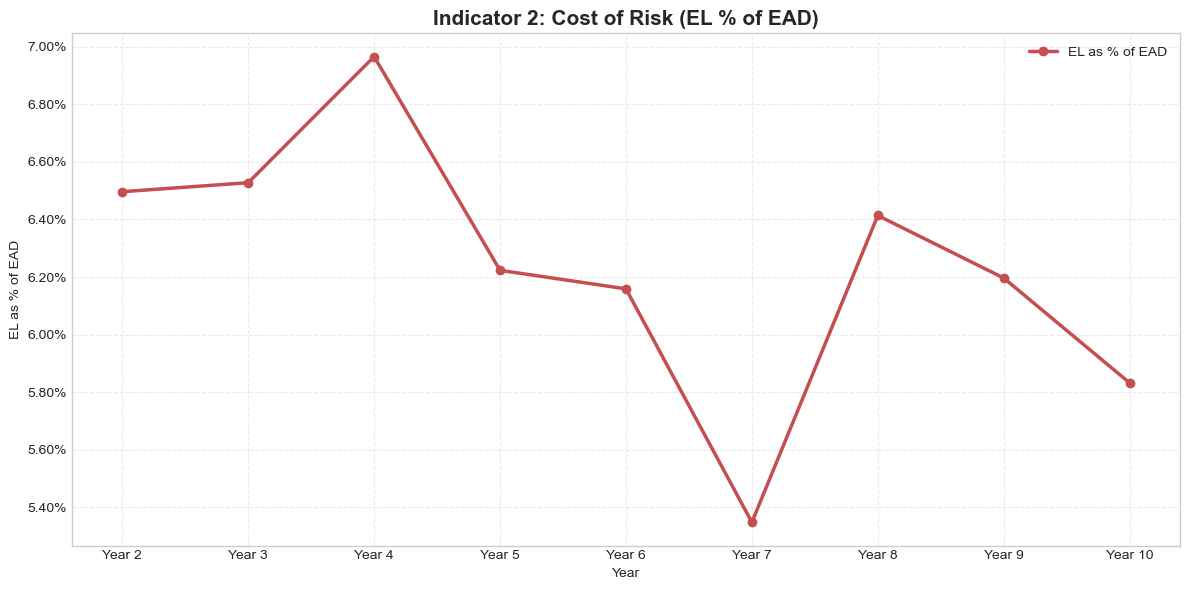

In [89]:
print("\n INDICATOR 2: Expected Loss as % of EAD ")

# contains EL % of EAD and YoY change
el_pct = df_portfolio['EL_%_of_EAD']
el_pct_yoy = el_pct.diff()

# build DataFrame
el_monitor_df = pd.DataFrame({
    'EL_%_of_EAD': el_pct,
    'YoY_Change_EL_%': el_pct_yoy
})

print(el_monitor_df.to_string(float_format=lambda x: f"{x:.2%}", na_rep='-'))

# Plot
plt.figure(figsize=(12, 6))

plt.plot(
    el_monitor_df.index,
    el_monitor_df['EL_%_of_EAD'],
    marker='o',
    linewidth=2.5,
    color='#c44e52',
    label='EL as % of EAD'
)

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.title('Indicator 2: Cost of Risk (EL % of EAD)', fontsize=15, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('EL as % of EAD')

plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()



 INDICATOR 3: Portfolio Composition (High-Risk Share) 
Year 1    49.54%
Year 2    50.82%
Year 3    49.62%
Year 4    50.81%
Year 5    50.53%
Year 6    52.56%
Year 7    48.49%
Year 8    50.79%
Year 9    49.55%
Year 10   48.94%


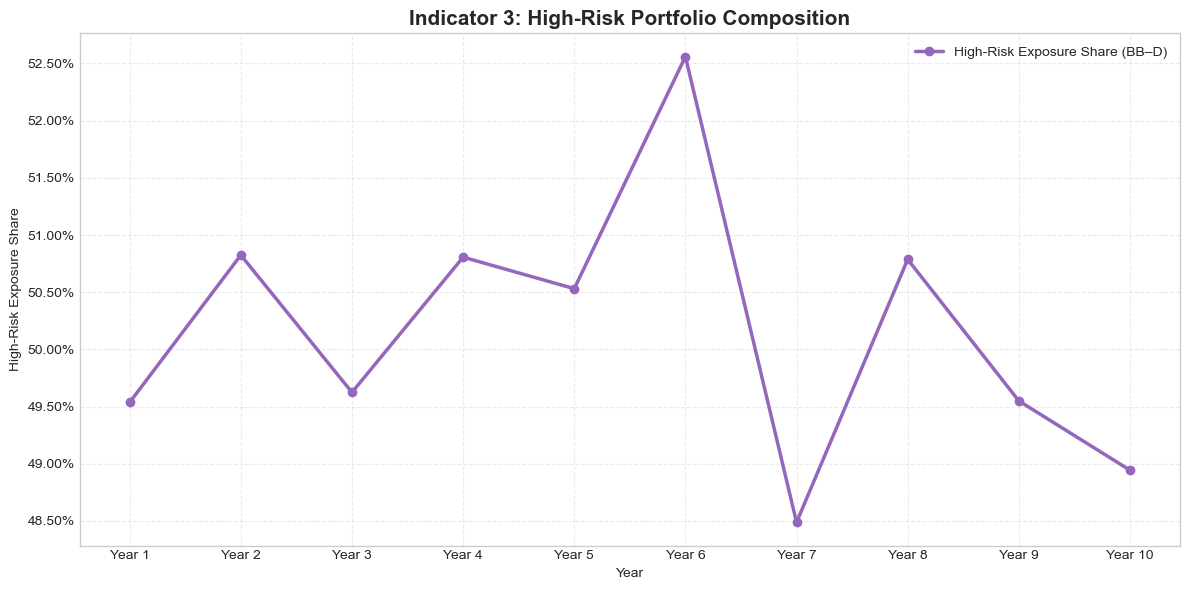

In [90]:
# define high-risk ratings
high_risk_ratings = ['BB', 'B', 'C', 'D']
print("\n INDICATOR 3: Portfolio Composition (High-Risk Share) ")

# Calculate yearly composition by rating
composition = {}

# for each year, calculate exposure share by rating
for year in df_ratings.columns:
    df_year = pd.DataFrame({
        'Rating': df_ratings[year],
        'Exposure': df_ead[year]
    }).dropna()
    
    # total exposure by rating
    exposure_by_rating = (
        df_year
        .groupby('Rating')['Exposure']
        .sum()
        .reindex(RATING_ORDER, fill_value=0)
    )

    total_exposure = exposure_by_rating.sum()

    composition[year] = (
        exposure_by_rating / total_exposure if total_exposure > 0 else exposure_by_rating
    )

composition_df = pd.DataFrame(composition).T

# High-risk share
high_risk_share = composition_df[high_risk_ratings].sum(axis=1)

print(high_risk_share.to_string(float_format=lambda x: f"{x:.2%}"))

plt.figure(figsize=(12, 6))

plt.plot(
    high_risk_share.index,
    high_risk_share.values,
    marker='o',
    linewidth=2.5,
    color='#9467bd',
    label='High-Risk Exposure Share (BB–D)'
)

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.title('Indicator 3: High-Risk Portfolio Composition', fontsize=15, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('High-Risk Exposure Share')

plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


## Model Limitations and Risk Considerations

While the analysis provides useful insights, the following limitations should be noted:

- The model does not account for correlation or systemic risk across borrowers.
- LGD is assumed static and not explicitly linked to macroeconomic conditions.
- PDs are backward-looking and may not fully capture forward-looking credit risk.
- Exposure amortization, prepayments, and recoveries over time are not modeled.
- Transition probabilities are assumed stable across the analysis horizon.

These limitations imply that results should be interpreted as indicative rather than predictive.


## Business Interpretation & Risk Management Actions

The quantitative outputs of this analysis (PD, Expected Loss, stress tests, and stability metrics)
are not an end in themselves. In a real banking or NBFC environment, these results directly inform
credit policy, pricing, capital allocation, and portfolio strategy.

### 1. Credit Underwriting & Origination Strategy
- Ratings with **low stability** and **high downgrade/default probabilities** (e.g., B, C buckets)
  indicate weaker credit quality.
- The bank would respond by:
  - Tightening underwriting standards for these segments
  - Reducing new loan origination in unstable rating categories
  - Introducing stricter covenants or collateral requirements

### 2. Risk-Based Pricing
- Higher **rating-wise PD and EL** imply higher expected losses.
- The bank would:
  - Increase interest spreads or fees for riskier rating buckets
  - Reprice loans dynamically based on observed migration behaviour
  - Avoid uniform pricing across heterogeneous risk profiles

### 3. Portfolio Rebalancing & Exposure Limits
- Rising **high-risk exposure share (BB–D)** is a leading indicator of portfolio deterioration.
- Risk teams would:
  - Set exposure caps for lower rating categories
  - Actively rebalance towards stable, high-quality ratings (AAA–A)
  - Slow down growth in segments showing persistent downgrades

### 4. Capital Planning & Provisioning
- Expected Loss (EL) feeds directly into:
  - Loan loss provisioning
  - Economic capital and regulatory capital buffers
- Stress testing results help management:
  - Quantify downside risk under adverse scenarios
  - Ensure sufficient capital is available during economic downturns
  - Meet regulatory stress-testing expectations

### 5. Early Warning & Risk Monitoring
- The risk dashboard (Portfolio PD, EL %, and Composition metrics) enables:
  - Early detection of structural risk shifts
  - Differentiation between temporary volatility and persistent deterioration
- Management action is triggered when:
  - Portfolio PD breaches predefined risk thresholds
  - EL as % of EAD shows a sustained upward trend
  - High-risk asset share increases over multiple years

### 6. Strategic Decision-Making
- Collectively, these outputs allow senior management to:
  - Decide whether to grow, shrink, or exit certain credit segments
  - Align business growth with risk appetite
  - Communicate portfolio risk transparently to regulators and investors

In summary, this framework transforms raw credit data into actionable insights that support
both **day-to-day risk control** and **long-term strategic planning**.


## Final Conclusion

This credit risk analysis integrates migration dynamics, loss modeling, and stress testing to provide
a holistic view of portfolio credit quality.

The combined use of PD, EL, stability metrics, and composition indicators enables identification of both
lagging and leading risk signals. Stress scenarios demonstrate that adverse migration and severity shocks
can materially increase expected losses.

Overall, the framework provides a robust foundation for portfolio-level credit risk monitoring and
can be extended to incorporate macroeconomic scenarios, borrower correlation, and regulatory capital analysis.
